<div style="background:#1E1E1E;border:1px solid #333333;color:#D4D4D4;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif;">
  <div style="font-size:13px;letter-spacing:2px;color:#4DD0E1;font-weight:700;">UNIVERSIDAD AUT&Oacute;NOMA DE GUADALAJARA</div>
  <div style="font-size:26px;font-weight:700;margin-top:6px;color:#FFFFFF;">Examen — Primer Parcial · SOLUCIÓN</div>
  <div style="font-size:16px;margin-top:4px;color:#A0A0A0;">Unidad 3 (Tuberías de aprendizaje automático) y Unidad 4 (Ingeniería de funciones)</div>
  <div style="margin-top:14px;font-size:14px;">
    <span style="background:rgba(232, 145, 43, 0.2);color:#F5B041;border:1px solid #E8912B;padding:4px 12px;border-radius:14px;font-weight:700;">FP13 &middot; Inteligencia Artificial</span>
    <span style="background:rgba(15, 163, 177, 0.2);color:#4DD0E1;border:1px solid #0FA3B1;padding:4px 12px;border-radius:14px;font-weight:700;margin-left:8px;">90 minutos</span>
    <span style="background:#2D2D2D;color:#E0E0E0;border:1px solid #444444;padding:4px 12px;border-radius:14px;font-weight:700;margin-left:8px;">100 puntos</span>
  </div>
</div>

**Alumno:** Chelsea Nicole Merryman Gonzalez  **Matrícula:** 4709857  **Fecha:** 14 de septiembre de 2026

<br>

---

### Instrucciones

1. El examen es **enteramente práctico**. Se resuelve dentro de este notebook.
2. Las celdas marcadas **`CELDA DADA`** ya están resueltas: **ejecútalas sin modificarlas**. Contienen el diagnóstico que necesitas para decidir.
3. Las celdas marcadas **`TU TURNO`** son tuyas. Escribe el código de la decisión.
4. Después de cada punto hay una celda de **justificación obligatoria**. Una decisión correcta sin evidencia que la respalde vale **la mitad**.
5. Ejecuta el notebook **de principio a fin, en orden**. Si una celda falla, las siguientes fallarán.

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Cómo se califica cada punto</b><br><b>Ejecución (50 %)</b>: el código corre y hace lo que dice.<br><b>Decisión (30 %)</b>: la elección es la que el dato exige.<br><b>Justificación (20 %)</b>: citas la evidencia numérica concreta.<br>
</div>

---

### Contexto clínico

Trabajas con el registro de una **cohorte de síndrome coronario agudo (SICA)** de un hospital de tercer nivel.
Cada fila es un **ingreso hospitalario**. El objetivo es predecir `reingreso_30d`: si el paciente reingresa
dentro de los 30 días posteriores al alta.

### Diccionario de datos

| Variable | Tipo | Descripción | Momento del registro |
|---|---|---|---|
| `id_paciente` | Texto | Identificador del paciente | — |
| `edad` | Numérica | Años cumplidos | Ingreso |
| `sexo` | Categórica nominal | M / F | Ingreso |
| `clase_nyha` | Categórica **ordinal** | Clase funcional NYHA: I < II < III < IV | Ingreso |
| `estadio_erc` | Categórica **ordinal** | Estadio de enfermedad renal crónica (KDIGO): 1 < 2 < 3 < 4 < 5 | Ingreso |
| `servicio_ingreso` | Categórica nominal | Unidad médica de admisión (código interno) | Ingreso |
| `presion_sistolica` | Numérica | Presión arterial sistólica (mmHg) | Ingreso |
| `fevi_ingreso` | Numérica | Fracción de eyección del ventrículo izquierdo (%) | Ingreso |
| `creatinina` | Numérica | Creatinina sérica (mg/dL) | Ingreso |
| `dimero_d` | Numérica | Dímero D (ng/mL) | Ingreso |
| `delta_fevi` | Numérica | Cambio en la fracción de eyección respecto al estudio previo (**puntos porcentuales, puede ser negativo**) | Ingreso |
| `pro_bnp` | Numérica | NT-proBNP (pg/mL). **Se solicita a criterio médico, no de forma sistemática** | Ingreso |
| `disnea_ingreso` | Binaria | Disnea presente al ingreso (0/1) | Ingreso |
| `dias_estancia_uci` | Numérica | Días de estancia en la Unidad de Cuidados Intensivos. **Se captura al cierre del expediente, en el momento del alta** | **Alta** |
| `reingreso_30d` | Binaria | **Variable objetivo**: reingreso a 30 días (0/1) | Seguimiento |


In [1]:
# ============================================================
#  CELDA DADA — ejecútala sin modificarla
# ============================================================
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

SEMILLA = 42


def lambda_ic(x, alpha=0.05):
    """Lambda de Yeo-Johnson por maxima verosimilitud + IC 95 % (verosimilitud perfilada).

    Devuelve (lambda, limite_inferior, limite_superior).
    Si el IC contiene 1.0, la transformacion NO es estadisticamente necesaria.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    lam = stats.yeojohnson_normmax(x)
    corte = stats.yeojohnson_llf(lam, x) - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    malla = np.linspace(lam - 6, lam + 6, 2001)
    llf = np.array([stats.yeojohnson_llf(l, x) for l in malla])
    dentro = malla[llf >= corte]
    return lam, dentro.min(), dentro.max()


def perfil(df, columnas):
    """Tabla diagnostica: sesgo, minimo, negativos, ceros, lambda e IC 95 %."""
    filas = []
    for c in columnas:
        s = df[c].dropna().astype(float)
        lam, lo, hi = lambda_ic(s)
        filas.append({
            "variable": c,
            "sesgo": round(float(stats.skew(s)), 2),
            "min": round(float(s.min()), 2),
            "negativos": int((s < 0).sum()),
            "ceros": int((s == 0).sum()),
            "lambda": round(lam, 3),
            "IC_inf": round(lo, 2),
            "IC_sup": round(hi, 2),
            "IC_contiene_1": bool(lo <= 1 <= hi),
        })
    return pd.DataFrame(filas)


def cargar(nombre):
    """Busca el CSV junto al notebook o en ./datos/."""
    for r in (nombre, os.path.join("datos", nombre),
              os.path.join("..", "datos", nombre)):
        if os.path.exists(r):
            return pd.read_csv(r)
    raise FileNotFoundError(
        f"No encuentro '{nombre}'. Colocalo en la misma carpeta que este notebook.")


print("Entorno listo.")

Entorno listo.


In [2]:
df = cargar("cohorte_sica_examen.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1210, 15)


,id_paciente,edad,sexo,clase_nyha,estadio_erc,servicio_ingreso,presion_sistolica,fevi_ingreso,creatinina,dimero_d,delta_fevi,pro_bnp,disnea_ingreso,dias_estancia_uci,reingreso_30d
0,SICA-00504,62.0,F,II,5,UM-25,162.0,25.0,6.21,790.4,-7.0,281.0,1,2,0
1,SICA-00939,61.0,M,IV,1,UM-03,120.0,45.0,0.96,202.3,6.0,NaN,0,1,0
2,SICA-00463,52.0,M,III,1,UM-04,110.0,60.0,1.10,325.0,3.0,NaN,0,3,0
3,SICA-00317,52.0,M,II,3,UM-21,102.0,50.0,1.42,348.5,-1.0,266.0,1,1,0
4,SICA-00894,39.0,F,I,4,UM-02,130.0,62.0,3.15,188.9,0.0,141.0,1,0,0


---
## Punto 1 — Integridad de los registros y segregación de datos &nbsp;&nbsp;`12 pts`
*Subtemas 3.2 y 3.4*

In [3]:
# ============================ CELDA DADA ============================
print("Filas (ingresos):     ", len(df))
print("Pacientes únicos:     ", df["id_paciente"].nunique())
print("Diferencia:           ", len(df) - df["id_paciente"].nunique())
print()
print("Pacientes con más de un ingreso (primeros 5):")
print(df["id_paciente"].value_counts().head(5).to_string())
print()
pac = df.groupby("id_paciente", as_index=False)["reingreso_30d"].max()
print("Resumen a nivel PACIENTE -> filas:", len(pac),
      "| prevalencia: %.4f" % pac["reingreso_30d"].mean())

Filas (ingresos):      1210
Pacientes únicos:      950
Diferencia:            260

Pacientes con más de un ingreso (primeros 5):
id_paciente
SICA-00070    4
SICA-00178    4
SICA-00052    3
SICA-00745    3
SICA-00650    3

Resumen a nivel PACIENTE -> filas: 950 | prevalencia: 0.0874


**Pregunta.** Construye el conjunto de entrenamiento (`df_tr`) y el de prueba (`df_te`) con
`test_size=0.25`, `random_state=SEMILLA` y estratificando por el *`reingreso_30d`*.

Antes de escribir, mira el diagnóstico de arriba y decide **sobre qué unidad debe hacerse la partición**.
La tabla `pac` ya está construida por si te resulta útil.

In [4]:
# ============================= TU TURNO =============================
# Objetivo: df_tr y df_te
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_split = df.drop_duplicates(subset="id_paciente")

df_tr, df_te = train_test_split(
    df_split,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=df_split["reingreso_30d"]
)

In [5]:
# ============================ CELDA DADA ============================
# Verificación de tu partición
solapamiento = set(df_tr["id_paciente"]) & set(df_te["id_paciente"])
print("Filas train / test:        ", len(df_tr), "/", len(df_te))
print("Pacientes compartidos:     ", len(solapamiento), "  <-- debe ser 0")
print("Prevalencia train:          %.4f" % df_tr["reingreso_30d"].mean())
print("Prevalencia test:           %.4f" % df_te["reingreso_30d"].mean())

Filas train / test:         712 / 238
Pacientes compartidos:      0   <-- debe ser 0
Prevalencia train:          0.0660
Prevalencia test:           0.0672



> **Tu justificación (obligatoria):**
>
> Se evito que el mismo paciente apareciera en train y test para prevenir el data leakage. Asi la evaluacion evita resultados falsos elevados.


---
## Punto 2 — Selección de funciones: variables admisibles &nbsp;&nbsp;`8 pts`
*Subtemas 3.1 y 4.1*

In [6]:
# ============================ CELDA DADA ============================
numericas = df_tr.select_dtypes(include=np.number).columns.drop("reingreso_30d")
corr = df_tr[numericas].corrwith(df_tr["reingreso_30d"]).sort_values(key=abs, ascending=False)
print("Correlación de cada variable numérica con el desenlace:")
print(corr.round(3).to_string())

Correlación de cada variable numérica con el desenlace:
dias_estancia_uci    0.841
creatinina           0.263
estadio_erc          0.160
dimero_d             0.086
delta_fevi          -0.081
fevi_ingreso        -0.075
presion_sistolica   -0.024
edad                -0.021
pro_bnp             -0.017
disnea_ingreso      -0.009


**Pregunta.** Una de estas variables **no puede formar parte del modelo**. Identifícala,
elimínala de `df_tr` y de `df_te`, y explica por qué.

> Pista: vuelve a leer la columna *"Momento del registro"* del diccionario de datos.

In [7]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr = df_tr.drop(columns=["dias_estancia_uci"])
df_te = df_te.drop(columns=["dias_estancia_uci"])


> **Tu justificación (obligatoria):**
>
> Se elimino la variable dias_estancia_uci, ya que era la que presentaba mayor correlacion, con un valor de 0.841.


---
## Punto 3 — Valores faltantes &nbsp;&nbsp;`12 pts`
*Subtema 3.3*

In [8]:
# ============================ CELDA DADA ============================
print("Porcentaje de faltantes por variable (entrenamiento):")
print((df_tr.isna().mean() * 100).round(1).loc[lambda s: s > 0].to_string())
print()
print("Faltantes de pro_bnp según disnea al ingreso:")
tabla = df_tr.groupby("disnea_ingreso")["pro_bnp"].agg(
    n="size", faltantes=lambda s: s.isna().sum(), pct_faltante=lambda s: round(s.isna().mean() * 100, 1))
print(tabla.to_string())

Porcentaje de faltantes por variable (entrenamiento):
pro_bnp    51.3

Faltantes de pro_bnp según disnea al ingreso:
                  n  faltantes  pct_faltante
disnea_ingreso                              
0               397        355          89.4
1               315         10           3.2


**Pregunta.** Trata los faltantes de `pro_bnp`. Antes de imputar, observa la tabla de arriba:
el patrón de ausencia **no es aleatorio**.

Tu solución debe (a) preservar la información contenida en el hecho mismo de que el estudio no se haya
solicitado, y (b) rellenar el valor numérico **sin usar información del conjunto de prueba**.

In [9]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["pro_bnp_faltante"] = df_tr["pro_bnp"].isna().astype(int)
df_te["pro_bnp_faltante"] = df_te["pro_bnp"].isna().astype(int)

mediana_bnp = df_tr["pro_bnp"].median()
df_tr["pro_bnp"] = df_tr["pro_bnp"].fillna(mediana_bnp)

df_te["pro_bnp"] = df_te["pro_bnp"].fillna(mediana_bnp)



> **Tu justificación (obligatoria):**
>
>Los faltantes de pro_bnp no son aleatorios, por lo que cree la variable para conservar la informacion de ausencia. El valor se imputo con la mediana del entrenamiento para evitar usar el conjunto de prueba.


---
## Punto 4 — Gestión de valores atípicos &nbsp;&nbsp;`14 pts`
*Subtema 4.3*

creatinina           límites IQR = [  -0.09,    2.55]   atípicos =   97   mínimo = 0.61
presion_sistolica    límites IQR = [  75.00,  195.00]   atípicos =   21   mínimo = 0.00

creatinina por estadio de enfermedad renal crónica (KDIGO):
             size  median   max
estadio_erc                    
1             216    0.86  1.39
2             213    0.99  1.52
3             176    1.50  2.12
4              73    3.07  4.16
5              34    6.78  9.32

presion_sistolica -> registros en cero: 20


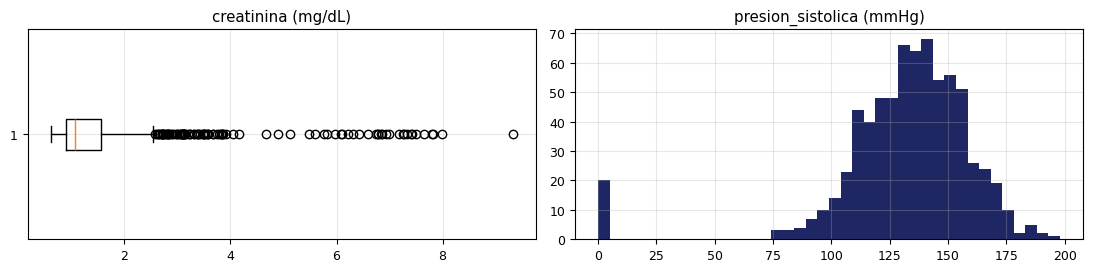

In [10]:
# ============================ CELDA DADA ============================
def limites_iqr(s):
    q1, q3 = s.quantile([.25, .75]); r = q3 - q1
    return q1 - 1.5 * r, q3 + 1.5 * r

for v in ["creatinina", "presion_sistolica"]:
    lo, hi = limites_iqr(df_tr[v])
    n = int(((df_tr[v] < lo) | (df_tr[v] > hi)).sum())
    print(f"{v:20s} límites IQR = [{lo:7.2f}, {hi:7.2f}]   atípicos = {n:4d}   mínimo = {df_tr[v].min():.2f}")

print("\ncreatinina por estadio de enfermedad renal crónica (KDIGO):")
print(df_tr.groupby("estadio_erc")["creatinina"].agg(["size", "median", "max"]).round(2).to_string())

print("\npresion_sistolica -> registros en cero:", int((df_tr["presion_sistolica"] == 0).sum()))
fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].boxplot(df_tr["creatinina"], vert=False); ax[0].set_title("creatinina (mg/dL)")
ax[1].hist(df_tr["presion_sistolica"], bins=40, color="#1E2664"); ax[1].set_title("presion_sistolica (mmHg)")
plt.tight_layout(); plt.show()

**Pregunta.** El criterio IQR marca valores atípicos en **ambas** variables.
**Solo una de las dos debe corregirse.** Decide cuál, aplica el tratamiento, y explica por qué la otra
se deja intacta.

In [11]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["presion_sistolica"] = df_tr["presion_sistolica"].replace(0, np.nan)

mediana_presion = df_tr["presion_sistolica"].median()

df_tr["presion_sistolica"] = df_tr["presion_sistolica"].fillna(mediana_presion)
df_te["presion_sistolica"] = df_te["presion_sistolica"].fillna(mediana_presion)


> **Tu justificación (obligatoria):**
>
> Aunque hay valores extranos en ambas variables, solo se corrigio la presion porque tiene registros con valor cero, los cuales no son posibles y representan errores. La creatinina se mantuvo sin cambios.


---
## Punto 5 — Codificación de variables categóricas &nbsp;&nbsp;`14 pts`
*Subtemas 4.4 y 4.7*

In [12]:
# ============================ CELDA DADA ============================
for v in ["sexo", "clase_nyha", "estadio_erc", "servicio_ingreso"]:
    print(f"{v:20s} niveles = {df_tr[v].nunique():3d}")
print()
print("clase_nyha:"); print(df_tr["clase_nyha"].value_counts().to_string())
print()
print("servicio_ingreso -> 8 niveles más frecuentes de", df_tr["servicio_ingreso"].nunique(), ":")
print(df_tr["servicio_ingreso"].value_counts().head(8).to_string())

sexo                 niveles =   2
clase_nyha           niveles =   4
estadio_erc          niveles =   5
servicio_ingreso     niveles =  25

clase_nyha:
clase_nyha
II     232
III    216
I      167
IV      97

servicio_ingreso -> 8 niveles más frecuentes de 25 :
servicio_ingreso
UM-01    130
UM-02     90
UM-03     81
UM-04     59
UM-05     44
UM-07     34
UM-06     34
UM-09     32


**Pregunta.** Codifica las cuatro variables categóricas. **No todas admiten el mismo tratamiento.**
Revisa en el diccionario cuáles son nominales y cuáles ordinales, y observa la cardinalidad.

Crea las columnas nuevas con estos nombres para que la celda de ensamblado funcione:
`nyha_ord`, `servicio_grp` (las demás las genera `get_dummies`).

In [13]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
map_nyha = {
    "I": 1,
    "II": 2,
    "III": 3,
    "IV": 4
}

df_tr["nyha_ord"] = df_tr["clase_nyha"].map(map_nyha)
df_te["nyha_ord"] = df_te["clase_nyha"].map(map_nyha)

df_tr["estadio_erc"] = df_tr["estadio_erc"].astype(int)
df_te["estadio_erc"] = df_te["estadio_erc"].astype(int)

frecuentes = df_tr["servicio_ingreso"].value_counts().head(8).index

df_tr["servicio_grp"] = np.where(
    df_tr["servicio_ingreso"].isin(frecuentes),
    df_tr["servicio_ingreso"],
    "OTROS"
)

df_te["servicio_grp"] = np.where(
    df_te["servicio_ingreso"].isin(frecuentes),
    df_te["servicio_ingreso"],
    "OTROS"
)
# nyha_ord      -> ...
# estadio_erc   -> ...
# servicio_grp  -> ...
# sexo          -> ...

In [14]:
# ============================ CELDA DADA ============================
# Ensamblado del one-hot para las variables NOMINALES y alineación de columnas
df_tr = pd.get_dummies(df_tr, columns=["sexo", "servicio_grp"], drop_first=True, dtype=int)
df_te = pd.get_dummies(df_te, columns=["sexo", "servicio_grp"], drop_first=True, dtype=int)
df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)   # el test debe tener las mismas columnas
print("Columnas tras codificar -> train:", df_tr.shape[1], "| test:", df_te.shape[1])

Columnas tras codificar -> train: 24 | test: 24



> **Tu justificación (obligatoria):**
>
> Las variables fueron tratadas como corresponde. Las variables clase_nyha y estadio_erc fueron transformadas y las variables sexo y servicio_ingreso fueron codificadas con one-hot encoding. Las categorías menos frecuentes fueron agrupadas en una categoría "OTROS" para evitar demasiadas variables.


---
## Punto 6 — Corrección del sesgo &nbsp;&nbsp;`20 pts`
*Subtema 4.5 — el punto de mayor peso del examen*

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Recordatorio de criterio</b><br>El logaritmo exige valores <b>estrictamente positivos</b>.<br>Yeo-Johnson admite ceros y negativos, y estima &lambda; por m&aacute;xima verosimilitud.<br>&lambda; &lt; 1 corrige sesgo <b>derecho</b>; &lambda; &gt; 1 corrige sesgo <b>izquierdo</b>.<br>Si el <b>IC 95 % de &lambda; contiene 1.0</b>, la transformaci&oacute;n no es estad&iacute;sticamente necesaria.
</div>

    variable  sesgo  min  negativos  ceros  lambda  IC_inf  IC_sup  IC_contiene_1
     pro_bnp   7.06 33.0          0      0   0.011   -0.04    0.06          False
    dimero_d   4.25 48.9          0      0  -0.001   -0.07    0.07          False
  delta_fevi   1.88 -7.0        478     28   0.627    0.59    0.67          False
fevi_ingreso  -1.07 18.0          0      0   3.049    2.66    3.45          False
        edad  -0.09 28.0          0      0   1.145    0.83    1.47           True


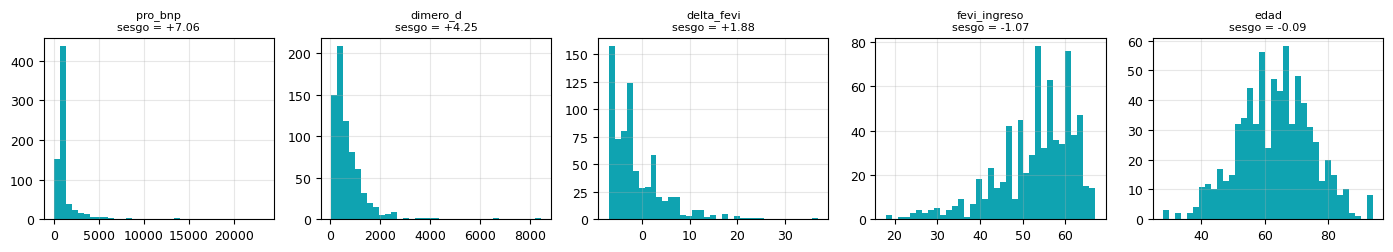

In [15]:
# ============================ CELDA DADA ============================
objetivo = ["pro_bnp", "dimero_d", "delta_fevi", "fevi_ingreso", "edad"]
print(perfil(df_tr, objetivo).to_string(index=False))

fig, ax = plt.subplots(1, 5, figsize=(14, 2.6))
for a, v in zip(ax, objetivo):
    a.hist(df_tr[v], bins=35, color="#0FA3B1")
    a.set_title(f"{v}\nsesgo = {stats.skew(df_tr[v].dropna()):+.2f}", fontsize=8)
plt.tight_layout(); plt.show()

**Pregunta.** Las cinco variables presentan situaciones **distintas**. Decide qué hacer con cada una.

La primera (`pro_bnp`) **ya viene resuelta como ejemplo**: úsala como modelo del formato esperado.
Resuelve las **cuatro restantes**.

> Advertencia: `PowerTransformer` estandariza por omisión. Usa `standardize=False`, porque el escalamiento
> es una decisión aparte que tomarás en el Punto 7.

In [16]:
# ============================ CELDA DADA — EJEMPLO RESUELTO ============================
# pro_bnp: sesgo muy positivo, mínimo > 0, sin ceros ni negativos  ->  LOGARITMO
df_tr["pro_bnp"] = np.log(df_tr["pro_bnp"])
df_te["pro_bnp"] = np.log(df_te["pro_bnp"])
print("pro_bnp -> log | sesgo resultante: %+.2f" % stats.skew(df_tr["pro_bnp"]))

pro_bnp -> log | sesgo resultante: -0.07


In [17]:
# ============================= TU TURNO =============================
# dimero_d      -> ?
# delta_fevi    -> ?
# fevi_ingreso  -> ?
# edad          -> ?
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["dimero_d"] = np.log(df_tr["dimero_d"])
df_te["dimero_d"] = np.log(df_te["dimero_d"])

pt_delta = PowerTransformer(
    method="yeo-johnson",
    standardize=False)

df_tr["delta_fevi"] = pt_delta.fit_transform(
    df_tr[["delta_fevi"]])

df_te["delta_fevi"] = pt_delta.transform(
    df_te[["delta_fevi"]])

pt_fevi = PowerTransformer(
    method="yeo-johnson",
    standardize=False)

df_tr["fevi_ingreso"] = pt_fevi.fit_transform(
    df_tr[["fevi_ingreso"]])

df_te["fevi_ingreso"] = pt_fevi.transform(
    df_te[["fevi_ingreso"]])

for v in objetivo:
    print(
        "%-18s sesgo tras la decisión: %+.2f"
        % (v, stats.skew(df_tr[v])))

pro_bnp            sesgo tras la decisión: -0.07
dimero_d           sesgo tras la decisión: -0.00
delta_fevi         sesgo tras la decisión: +0.24
fevi_ingreso       sesgo tras la decisión: -0.18
edad               sesgo tras la decisión: -0.09


> **Tu justificación (obligatoria).** Completa la tabla:
>
> | Variable | Decisión | Evidencia numérica que la sustenta |
> |---|---|---|
> | `dimero_d` |logaritmo|+4.25 |
> | `delta_fevi` |yeo-johnson|+1.88|
> | `fevi_ingreso` |yeo-johnson|-1.07|
> | `edad` |No se transforma |-0.09|


---
## Punto 7 — Escalamiento &nbsp;&nbsp;`10 pts`
*Subtema 4.6*

In [18]:
# ============================ CELDA DADA ============================
num_final = ["edad", "presion_sistolica", "fevi_ingreso", "creatinina",
             "dimero_d", "delta_fevi", "pro_bnp", "nyha_ord", "estadio_erc"]
print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())
print("\nSesgo residual de cada variable:")
print(df_tr[num_final].apply(lambda s: round(float(stats.skew(s)), 2)).to_string())

                       mean       std      min       50%        max
edad                  63.30     11.50    28.00     63.00      94.00
presion_sistolica    135.89     20.57    75.00    137.00     198.00
fevi_ingreso       67688.00  28329.53  2599.61  66448.92  126899.24
creatinina             1.57      1.34     0.61      1.07       9.32
dimero_d               6.27      0.78     3.89      6.27       9.04
delta_fevi            -3.45      5.52   -11.92     -4.16      14.03
pro_bnp                6.75      0.82     3.50      6.75      10.06
nyha_ord               2.34      0.98     1.00      2.00       4.00
estadio_erc            2.29      1.14     1.00      2.00       5.00

Sesgo residual de cada variable:
edad                -0.09
presion_sistolica   -0.10
fevi_ingreso        -0.18
creatinina           2.98
dimero_d            -0.00
delta_fevi           0.24
pro_bnp             -0.07
nyha_ord             0.14
estadio_erc          0.59


**Pregunta.** Escala las variables numéricas. **No todas deben recibir el mismo escalador.**

Recuerda la decisión que tomaste en el Punto 4: hay una variable cuyos valores extremos **conservaste
deliberadamente** porque son clínicamente válidos. Un escalador basado en media y desviación estándar
se ve arrastrado por ellos.

Deja el resultado en `df_tr[num_final]` y `df_te[num_final]`.

In [19]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
escalador = StandardScaler().fit(df_tr[num_final])
df_tr[num_final] = escalador.transform(df_tr[num_final])
df_te[num_final] = escalador.transform(df_te[num_final])
print(
    df_tr[num_final]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
    .to_string()
)


                   mean  std   min   max
edad                0.0  1.0 -3.07  2.67
presion_sistolica  -0.0  1.0 -2.96  3.02
fevi_ingreso       -0.0  1.0 -2.30  2.09
creatinina         -0.0  1.0 -0.72  5.77
dimero_d            0.0  1.0 -3.07  3.56
delta_fevi         -0.0  1.0 -1.53  3.17
pro_bnp            -0.0  1.0 -3.98  4.05
nyha_ord           -0.0  1.0 -1.36  1.69
estadio_erc         0.0  1.0 -1.13  2.37



> **Tu justificación (obligatoria):**
>
> Se escalo el conjunto de entrenamiento para evitar la fuga de info. La transformacion centra las variables y ajusta su escala.

---
## Punto 8 — Entrenamiento y elección de la métrica &nbsp;&nbsp;`10 pts`
*Subtemas 3.5 y 3.1*

In [20]:
# ============================ CELDA DADA ============================
descartar = ["id_paciente", "reingreso_30d", "clase_nyha", "servicio_ingreso"]
X_tr = df_tr.drop(columns=[c for c in descartar if c in df_tr.columns])
X_te = df_te.drop(columns=[c for c in descartar if c in df_te.columns])
y_tr, y_te = df_tr["reingreso_30d"], df_te["reingreso_30d"]

assert X_tr.select_dtypes(exclude=np.number).empty, "Quedan columnas no numéricas en X_tr"
print("Matriz final -> train:", X_tr.shape, "| test:", X_te.shape)
print("Prevalencia en prueba: %.4f" % y_te.mean())

modelo = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEMILLA).fit(X_tr, y_tr)
pred = modelo.predict(X_te)
prob = modelo.predict_proba(X_te)[:, 1]

print("\n--- MODELO A (sin ponderar) -------------------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred))
print("Recall   : %.4f" % recall_score(y_te, pred, zero_division=0))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob))
print("Matriz de confusión [fila = real, columna = predicho]:")
print(confusion_matrix(y_te, pred))

modelo_b = LogisticRegression(solver="lbfgs", max_iter=3000, class_weight="balanced",
                              random_state=SEMILLA).fit(X_tr, y_tr)
pred_b = modelo_b.predict(X_te)
prob_b = modelo_b.predict_proba(X_te)[:, 1]

print("\n--- MODELO B (class_weight='balanced') --------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred_b))
print("Recall   : %.4f" % recall_score(y_te, pred_b, zero_division=0))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob_b))
print("Matriz de confusión:")
print(confusion_matrix(y_te, pred_b))

print("\n--- Referencia: clasificador trivial 'nadie reingresa' ----------")
print("Accuracy : %.4f" % accuracy_score(y_te, np.zeros_like(y_te)))

Matriz final -> train: (712, 20) | test: (238, 20)
Prevalencia en prueba: 0.0672

--- MODELO A (sin ponderar) -------------------------------------
Accuracy : 0.9370
Recall   : 0.1250
AUC ROC  : 0.7469
Matriz de confusión [fila = real, columna = predicho]:
[[221   1]
 [ 14   2]]

--- MODELO B (class_weight='balanced') --------------------------
Accuracy : 0.7437
Recall   : 0.5625
AUC ROC  : 0.7255
Matriz de confusión:
[[168  54]
 [  7   9]]

--- Referencia: clasificador trivial 'nadie reingresa' ----------
Accuracy : 0.9328


**Pregunta.** Responde las tres, en prosa, con los números de la salida anterior:

1. El Modelo A alcanza una accuracy alta. ¿Es un buen modelo? Compáralo con el clasificador trivial.
2. ¿Qué métrica reportarías al comité clínico del hospital y por qué?
3. ¿Cuál de los dos modelos entregarías? Justifica en términos del **costo clínico** de cada tipo de error.

> **Tus respuestas:**
>
> **1.** El Modelo A tiene una accuracy alta, pero no es un buen modelo porque casi no mejora al clasificador trivial y tiene un recall bajo.
>
> **2.** Reportaria la metrica de recall, porque mide que tantos pacientes que reingresan logra detectar el modelo.
>
> **3.** Entregaria el Modelo B, porque aunque tiene menor accuracy, tiene mayor recall y menos falsos negativos. Es mejor detectar mas pacientes en riesgo y que falte, aunque a veces tenga alarmas que no son.


---
<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Antes de entregar</b><br>1. <b>Reinicia el kernel y ejecuta todo de nuevo</b> (Kernel &rarr; Restart &amp; Run All). El notebook debe correr de principio a fin sin errores.<br>2. Verifica que las ocho celdas de justificaci&oacute;n est&eacute;n escritas. Una decisi&oacute;n sin justificaci&oacute;n vale la mitad.<br>3. Guarda como <code>Parcial1_ApellidoNombre.ipynb</code> y s&uacute;belo a Mis Cursos.
</div>